In [251]:
%pip install numpy pandas seaborn matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [252]:
import numpy as np

In [253]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [254]:
df = pd.read_csv("sugurta.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [255]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [256]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [257]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

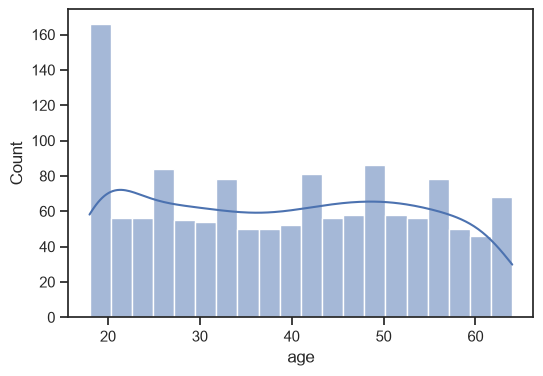

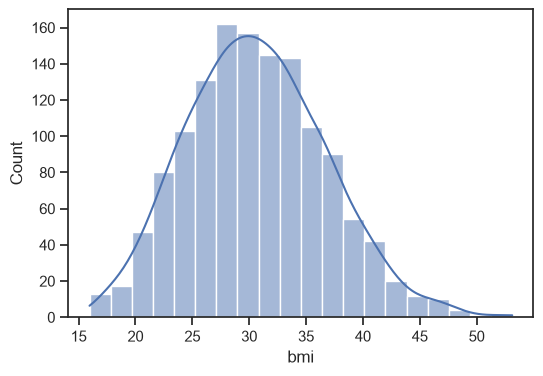

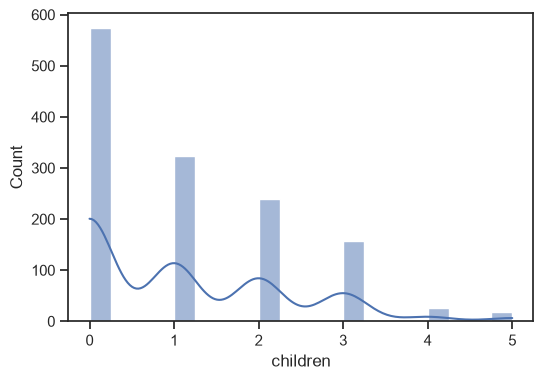

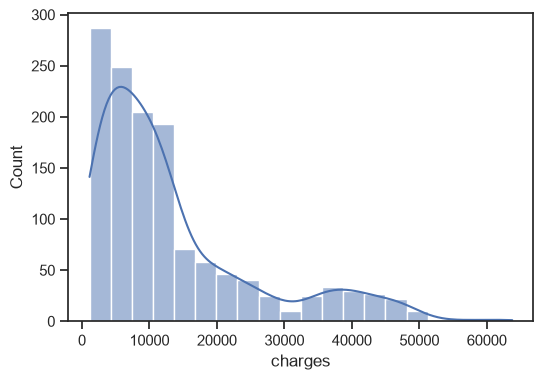

In [258]:
numeric_columns=['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='children', ylabel='count'>

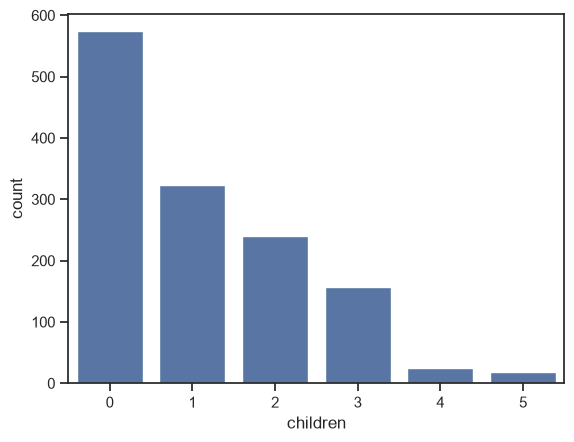

In [259]:
sns.countplot(x=df['children'])

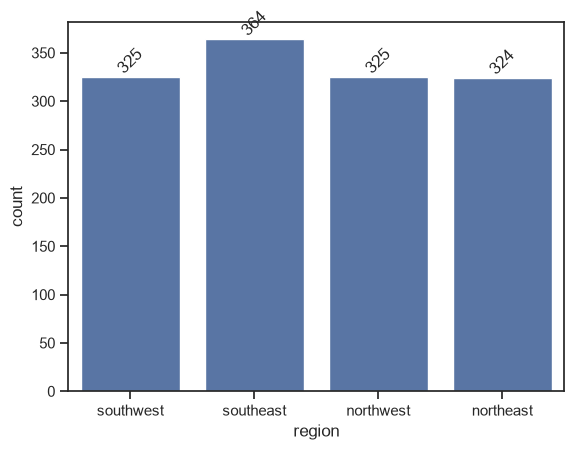

In [260]:
ax=sns.countplot(x=df['region'])
ax.bar_label(ax.containers[0],fmt='%.0f', rotation=45)
plt.show()

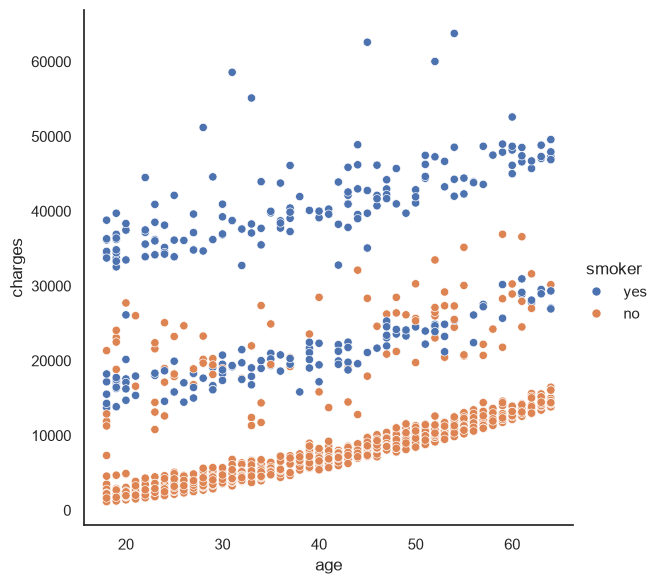

In [261]:
sns.set_theme(style="white")
sns.relplot( data=df,
             x="age", y="charges",
             hue="smoker",
             height=6)

<Axes: >

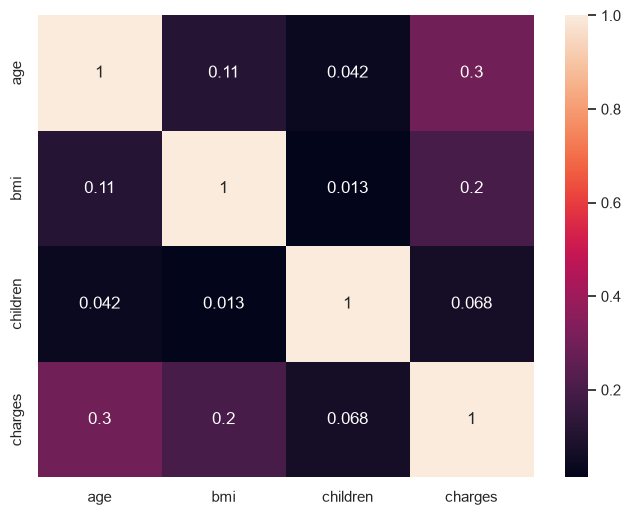

In [262]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

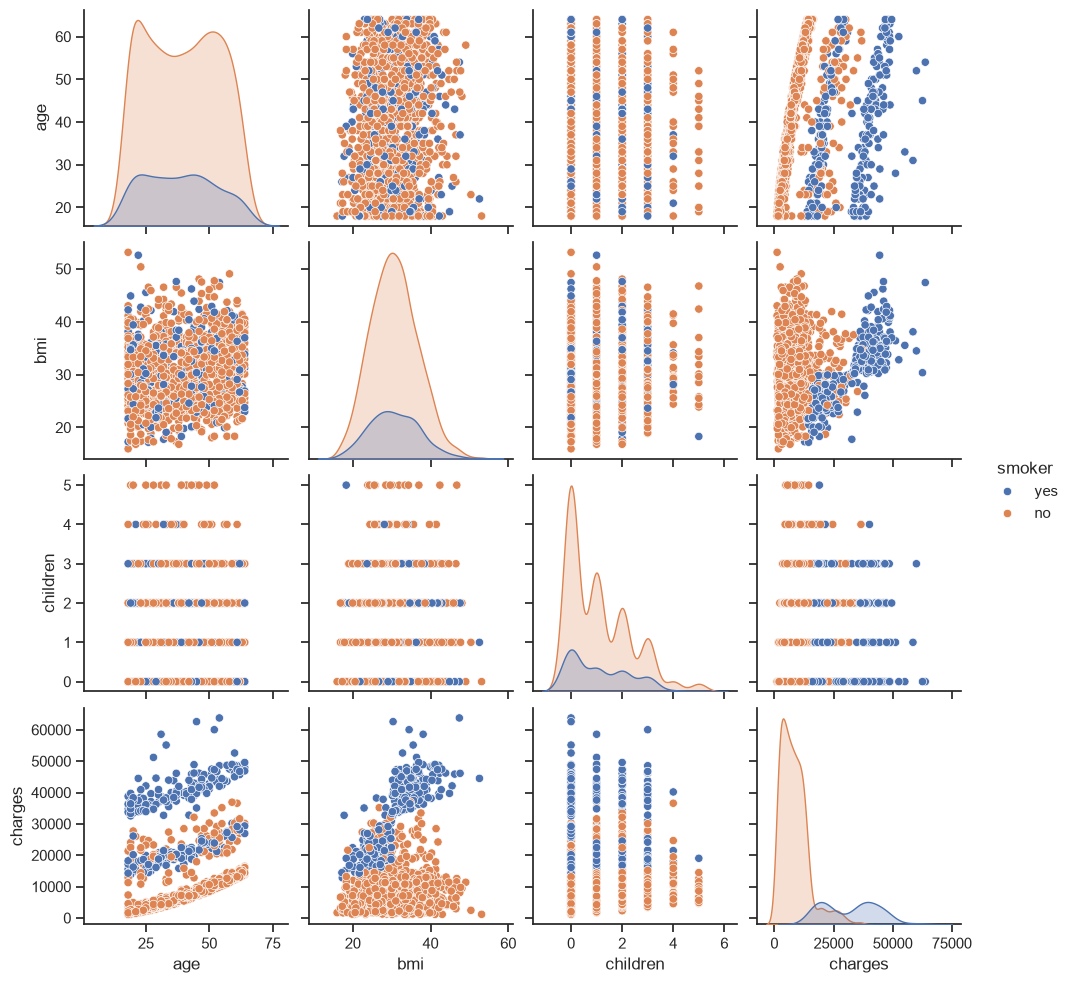

In [263]:
sns.set_theme(style="ticks")

df = pd.read_csv("sugurta.csv")
sns.pairplot(
    df,
    vars=["age", "bmi", "children", "charges"],
    hue="smoker",  
)

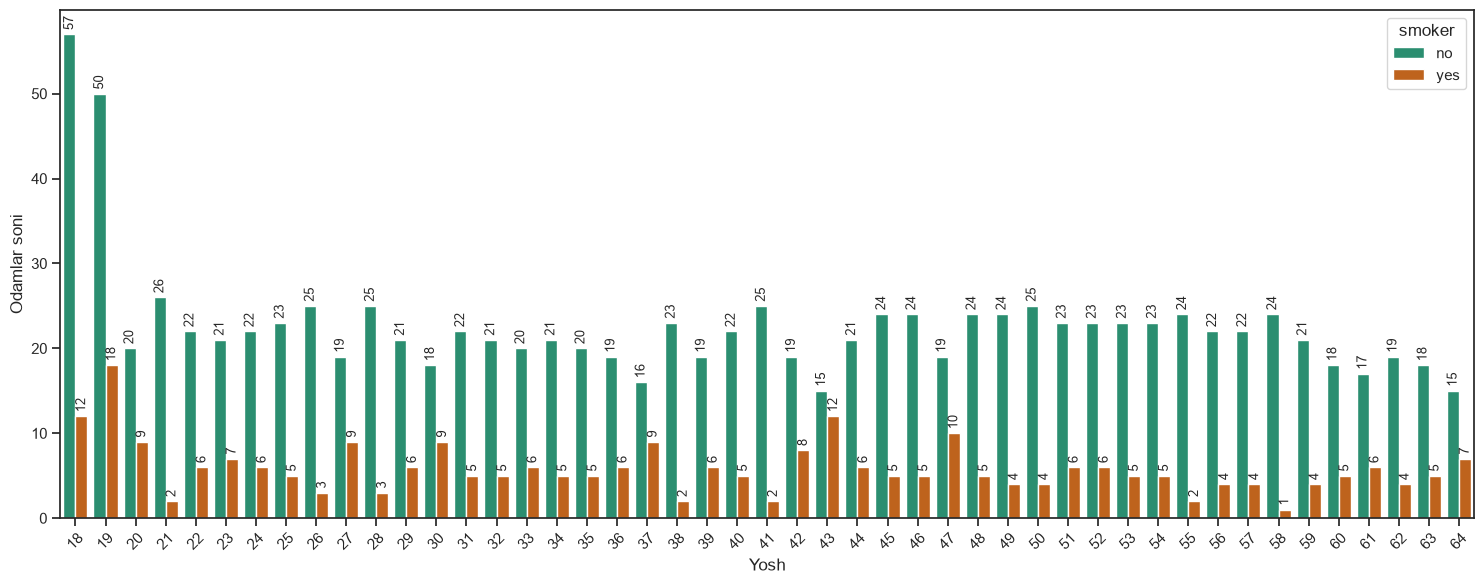

In [264]:
plt.figure(figsize=(15, 6))

ax = sns.countplot(data=df, x="age", hue="smoker", palette="Dark2")


for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', rotation=90, padding=3, fontsize=9)

plt.xlabel("Yosh", fontsize=12)
plt.ylabel("Odamlar soni", fontsize=12)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

In [265]:
df_cleaned = df.copy()

In [266]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [267]:
df_cleaned.shape

(1338, 7)

In [268]:
df_cleaned.drop_duplicates(inplace = True)

In [269]:
df_cleaned.shape

(1337, 7)

In [270]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [271]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [272]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [273]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male":0, "female":1})

In [274]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [275]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no":0, "yes":1})

In [276]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [277]:
df_cleaned.rename(columns={'sex':'is_famale',
                           'smoker':'is_smoker'}, inplace = True)

In [278]:
df_cleaned.head()

,age,is_famale,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [279]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [280]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [281]:
df_cleaned.head()

,age,is_famale,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [282]:
df_cleaned = df_cleaned.astype(int)

In [283]:
df_cleaned

,age,is_famale,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


In [284]:
# FEAUTE ENGINEERING AND EXTRACTION

<Axes: xlabel='bmi', ylabel='Count'>

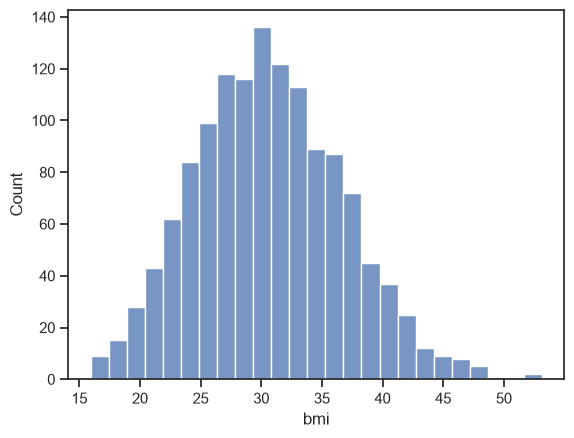

In [285]:
sns.histplot(df['bmi'])

In [286]:
df_cleaned['bmi_category'] = pd.cut(df_cleaned['bmi'],
                                    bins=[0,18.5,24.9, 29.9, float('inf')],
                                    labels = ['Underweight', 'Normal', 'Overweight','Obese'])

In [287]:
df_cleaned

,age,is_famale,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [288]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [289]:
df_cleaned

,age,is_famale,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,False,False,True
1334,18,1,31,0,0,2205,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,1,False,True,False


In [290]:
df_cleaned = df_cleaned.astype(int)

In [291]:
df_cleaned

,age,is_famale,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [292]:
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [293]:
# PEARSON CORRELATION CALCULATION

In [294]:
from scipy.stats import pearsonr

In [295]:
selected_features = ['age', 'bmi', 'children', 'is_famale', 'is_smoker', 'region_northwest', 'region_southwest'
                     'region_southwest', 'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese']

In [296]:
correlation = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
    if feature in df_cleaned.columns   
}

In [297]:
correlation_df = pd.DataFrame(list(correlation.items()),
                              columns=['Feature','Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation',ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
8,bmi_category_Obese,0.200348
1,bmi,0.196236
2,children,0.067390
5,region_northwest,-0.038695
3,is_famale,-0.058046
6,bmi_category_Normal,-0.104042
7,bmi_category_Overweight,-0.120601


In [298]:
cat_features = ['is_famale', 'is_smoker', 'region_northwest', 'region_southeast', 'region_southwest',
                'bmi_category_Normal', 'bmi_category_Overweight','bmi_category_Obese']

In [299]:
from scipy.stats import chi2_contingency

alpha = 0.05

In [300]:
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

In [301]:
for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null(Keep Feature)' if p_val < alpha else 'Accept Null(Drop Feature)'
    chi2_results[col] = {'chi2_statistic': chi2_stat, 'p_value': p_val, 'Decision': decision}

In [302]:
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null(Keep Feature)
region_southeast,15.998167,0.001135,Reject Null(Keep Feature)
is_famale,10.258784,0.01649,Reject Null(Keep Feature)
bmi_category_Obese,8.515711,0.036473,Reject Null(Keep Feature)
region_southwest,5.091893,0.165191,Accept Null(Drop Feature)
bmi_category_Overweight,4.25149,0.235557,Accept Null(Drop Feature)
bmi_category_Normal,3.708088,0.29476,Accept Null(Drop Feature)
region_northwest,1.13424,0.768815,Accept Null(Drop Feature)


In [303]:
final_df = df_cleaned[[
    'age', 'bmi', 'children', 'is_famale', 'is_smoker', 'charges',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]]
final_df

,age,bmi,children,is_famale,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,-0.517949,-0.909234,1,1,16884,0,0,1,0,1,0
1,-1.511647,0.462463,-0.079442,0,0,1725,0,1,0,0,0,1
2,-0.799350,0.462463,1.580143,0,0,4449,0,1,0,0,0,1
3,-0.443201,-1.334960,-0.909234,0,0,21984,1,0,0,1,0,0
4,-0.514431,-0.354547,-0.909234,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,-0.027743,1.580143,0,0,10600,1,0,0,0,0,1
1334,-1.511647,0.135659,-0.909234,1,0,2205,0,0,0,0,0,1
1335,-1.511647,0.952670,-0.909234,1,0,1629,0,1,0,0,0,1
1336,-1.297958,-0.844753,-0.909234,1,0,2007,0,0,1,0,1,0


In [304]:
# train va test. x va y ga ajratamiz

In [305]:
X = final_df.drop('charges', axis=1)
y = final_df['charges']

In [306]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [307]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=300,max_depth=10,random_state=42)
rf_model.fit(X_train,y_train)
print("model muvaffaqqiyatli oqitildi")

model muvaffaqqiyatli oqitildi


In [308]:
yangi_mijoz = pd.DataFrame([{'age':-0.5,
                             'bmi':0.2,
                             'children':0.0,
                             'is_famale':0,
                             'is_smoker':1,
                             'region_northwest':0,
                             'region_southeast':1,
                             'region_southwest':0,
                             'bmi_category_Normal':0,
                             'bmi_category_Overweight':0,
                             'bmi_category_Obese':1 }])
yangi_mijoz = yangi_mijoz[X.columns]
taxminiy_charge = rf_model.predict(yangi_mijoz)
print(f"taxmin qilingan sugurta xarajati: ${taxminiy_charge[0]:.2f}")

taxmin qilingan sugurta xarajati: $41589.84


In [309]:
#mean absolute error 

In [310]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
roots = mse ** 0.5
r2 = r2_score(y_test, pred)

print("Mean absolute error:", mae)
print("Mean squared error:", mse)
print("Root error:", roots)
print("R2: ", r2)

Mean absolute error: 2694.2208502174194
Mean squared error: 21612462.220648196
Root error: 4648.92054359377
R2:  0.8823850529470751


In [311]:
rf_model.fit(X_train,y_train)
pred = rf_model.predict(X_test)

In [312]:
natija = pd.DataFrame({
    "Actual": y_test,
    "Predicted":pred
})

#Error Actual Predicted
natija["Error"] = natija["Actual"] - natija["Predicted"]
print(natija)

      Actual     Predicted        Error
900     8688   8847.849092  -159.849092
1064    5708  10496.659187 -4788.659187
1256   11436  13567.542184 -2131.542184
298    38746  42881.503876 -4135.503876
237     4463   5645.066153 -1182.066153
...      ...           ...          ...
534    13831  14240.451735  -409.451735
542    13887  14172.999183  -285.999183
760     3925   8049.880451 -4124.880451
1284   47403  48163.158581  -760.158581
1285    8534  15862.625012 -7328.625012

[268 rows x 3 columns]
